In [4]:
# install/upgrade the libraries we need. fastcore<2 is pinned because a newer fastcore breaks fastai
!pip install -U fastai "fastcore<2" torchinfo grad-cam statsmodels -q

In [5]:
# connect this colab session to my google drive so i can read/write files there
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
from pathlib import Path   # for building file paths
import pandas as pd        # for building tables (dataframes) of image info

In [7]:
# paths to the two dataset folders on google drive (train+val images, and separate held-out test images)
TRAINING_VALIDATION_ROOT = Path("/content/drive/MyDrive/Masters/Datasets/train_and_validation_sets")
TEST_ROOT = Path("/content/drive/MyDrive/Masters/Datasets/test_set")

# where all outputs (csvs, images) get saved. on drive so they dont disappear when colab resets
RESULTS_DIR = Path("/content/drive/MyDrive/Masters/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def make_df(root):
    records = []
    for mayo_dir in sorted(root.iterdir()):
        # list everything in directory -> Mayo 0 etc. 
        # if not mayo folder then continue
        if not mayo_dir.is_dir():
            continue
        # create the label the same as the file
        label = mayo_dir.name
        # loop over every bmp file
        for img_path in mayo_dir.glob("*.bmp"):
            # break the naming convention UC_patient_135_10.bmp → "UC_patient_135_10". .split("_") breaks that on underscores into ["UC", "patient", "135", "10"].
            patient_id = img_path.stem.split("_")[2]
            records.append({"path": str(img_path), "label": label, "patient_id": patient_id})
            # exmaple of the df
            # path	                            label	patient_id
            #.../Mayo 0/UC_patient_135_10.bmp	Mayo 0	135
            #.../Mayo 2/UC_patient_338_4.bmp	Mayo 2	338
    return pd.DataFrame(records)

# actually build the two tables, one for train+val images, one for test images
training_validation_df = make_df(TRAINING_VALIDATION_ROOT)
test_df = make_df(TEST_ROOT)



# nicer names for each mayo grade, to show in the summary table
mes_labels = {
    "Mayo 0": "MES 0 (normal)",
    "Mayo 1": "MES 1 (mild)",
    "Mayo 2": "MES 2 (moderate)",
    "Mayo 3": "MES 3 (severe)",
}

# how many images of each grade in train+val vs test
training_validation_counts = training_validation_df["label"].value_counts()
test_counts = test_df["label"].value_counts()

# build a small table: one row per grade, columns = train+val count / test count
summary_df = pd.DataFrame({
    "MES Grade": list(mes_labels.values()),
    "Train + Val": [int(training_validation_counts.get(k, 0)) for k in mes_labels],
    "Test": [int(test_counts.get(k, 0)) for k in mes_labels],
})
summary_df["Total"] = summary_df["Train + Val"] + summary_df["Test"]   # add up train+val and test per row

# add one more row at the bottom with the grand totals
total_row = pd.DataFrame([{
    "MES Grade": "Total",
    "Train + Val": int(summary_df["Train + Val"].sum()),
    "Test": int(summary_df["Test"].sum()),
    "Total": int(summary_df["Total"].sum()),
}])
summary_df = pd.concat([summary_df, total_row], ignore_index=True)
# example of summary_df at this point:
# MES Grade         Train + Val   Test   Total
# MES 0 (normal)     5180          925    6105
# MES 1 (mild)       2588          464    3052
# MES 2 (moderate)   1077          177    1254
# MES 3 (severe)      745          120     865
# Total              9590         1686   11276

from IPython.display import display   # lets us show a styled html table instead of plain text
# show the table nicely styled (bold header/total row, numbers with commas) instead of a plain print
display(
    summary_df.style
    .hide(axis="index")   # dont show the 0,1,2... row numbers
    .format({"Train + Val": "{:,}", "Test": "{:,}", "Total": "{:,}"})   # 1234 -> 1,234
    .set_caption("Dataset Summary")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"),
                                           ("text-align", "left"), ("padding-bottom", "6px")]},
        {"selector": "th", "props": [("text-align", "left"), ("padding", "4px 16px")]},
        {"selector": "td", "props": [("text-align", "left"), ("padding", "4px 16px")]},
    ])
    .set_properties(subset=pd.IndexSlice[[len(summary_df) - 1], :], **{"font-weight": "bold"})   # make the Total row bold
)

MES Grade,Train + Val,Test,Total
MES 0 (normal),"5,180",925,"6,105"
MES 1 (mild),"2,588",464,"3,052"
MES 2 (moderate),"1,077",177,"1,254"
MES 3 (severe),745,120,865
Total,"9,590","1,686","11,276"


In [8]:
training_validation_df.head()   # peek at the first 5 rows of the table -> returns the first few rows of a DataFrame
training_validation_df.info()   # check column types and make sure nothing is missing (non-null counts) -> provides a technical summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9590 entries, 0 to 9589
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   path        9590 non-null   object
 1   label       9590 non-null   object
 2   patient_id  9590 non-null   object
dtypes: object(3)
memory usage: 224.9+ KB


In [9]:
import gc   # lets us manually free up memory later

import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score as sklearn_f1, cohen_kappa_score
from torchvision.models import mobilenet_v2, densenet121, efficientnet_b0
from fastai.vision.all import (
    ImageDataLoaders, Resize, aug_transforms, Normalize, imagenet_stats,
    vision_learner, resnet34, valley, accuracy, F1Score, Metric,
)

# True = quick test run (tiny data, 1 epoch, 1 model). False = the real full run
DEV_MODE = False

In [10]:
import random

# fix all the random number generators to the same seed so re-running gives the same result
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [11]:
def stratified_subsample(df, n_per_class, seed=42):
    # df.groupby("label") splits the df into one smaller df per mayo grade. g = that group's rows, _ = the label name (unused)
    # g.sample(n=...) randomly picks n rows out of that group. random_state=seed makes the "random" pick reproducible
    parts = [
        g.sample(n=min(n_per_class, len(g)), random_state=seed)
        for _, g in df.groupby("label")
    ]
    return pd.concat(parts).reset_index(drop=True)   # stick all the groups back together into one df

# if DEV_MODE, shrink both dataframes down to a tiny, balanced subset so we can test the pipeline fast
if DEV_MODE:
    N_PER_CLASS = 40   # how many images to keep per mayo grade for the quick test run (instead of the full dataset)
    training_validation_df = stratified_subsample(training_validation_df, N_PER_CLASS)
    test_df = stratified_subsample(test_df, N_PER_CLASS)
    print(f"[DEV_MODE] Subsetted to {len(training_validation_df)} train/val images, {len(test_df)} test images")

In [12]:
# Source (rationale for patient-level grouping to prevent data leakage in medical imaging):
# https://blog.dailydoseofds.com/p/random-splitting-can-be-fatal-for

# for each patient, find their most common (dominant) mayo grade across all their images
patient_dominant_label = (
    training_validation_df.groupby("patient_id")["label"]
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
    .rename(columns={"label": "dominant_label"})
)
# example of patient_dominant_label:
# patient_id   dominant_label
# 135          Mayo 0
# 338          Mayo 2
# 556          Mayo 1

patients = patient_dominant_label["patient_id"].values           # list of all patient ids
strata_labels = patient_dominant_label["dominant_label"].values   # each patient's dominant grade, same order

## split 80/20 
# split PATIENTS (not images) 80/20, keeping the same mix of grades on both sides (stratify=)
training_patients, validation_patients = train_test_split(
    patients,
    test_size=0.20,
    random_state=42,
    stratify=strata_labels,
)

validation_patients_set = set(validation_patients)
# mark every image as validation (True) or training (False) based on which patient it belongs to
training_validation_df["is_valid"] = training_validation_df["patient_id"].apply(lambda p: p in validation_patients_set)

print(f"Training patients: {len(training_patients)}")
print(f"Validation patients: {len(validation_patients)}")
print(f"Training images: {training_validation_df['is_valid'].eq(False).sum()}")
print(f"Validation images: {training_validation_df['is_valid'].eq(True).sum()}")

Training patients: 382
Validation patients: 96
Training images: 7826
Validation images: 1764


In [13]:
training_split_df = training_validation_df[~training_validation_df["is_valid"]]   # rows where is_valid is False -> training images
validation_split_df = training_validation_df[training_validation_df["is_valid"]]   # rows where is_valid is True -> validation images

print("Train split class distribution:")
print(training_split_df["label"].value_counts().sort_index())
print("\nValidation split class distribution:")
print(validation_split_df["label"].value_counts().sort_index())

training_patients_check = set(training_split_df["patient_id"])
validation_patients_check = set(validation_split_df["patient_id"])
# double check: make sure no single patient's images ended up in BOTH train and validation
assert training_patients_check.isdisjoint(validation_patients_check), "Patient leakage detected between train and validation splits!"
print("\nNo patient overlap between train and validation splits.")

Train split class distribution:
label
Mayo 0    4220
Mayo 1    2084
Mayo 2     913
Mayo 3     609
Name: count, dtype: int64

Validation split class distribution:
label
Mayo 0    960
Mayo 1    504
Mayo 2    164
Mayo 3    136
Name: count, dtype: int64

No patient overlap between train and validation splits.


In [14]:
# Source (ImageDataLoaders.from_df): https://docs.fast.ai/vision.data.html
# Source (aug_transforms params + Normalize.from_stats(*imagenet_stats)): https://docs.fast.ai/vision.augment.html
IMG_SIZE = 224     # resize every image to 224x224 pixels
BATCH_SIZE = 32    # how many images the model sees at once during training

# build fastai's DataLoaders - this feeds batches of (image, label) pairs to the model
dls = ImageDataLoaders.from_df(
    training_validation_df,
    path="/",                  # fn_col already has full paths, "/" makes that join correctly
    fn_col="path",              # column with the image file path
    label_col="label",          # column with the mayo grade
    is_valid_col="is_valid",    # column that says which rows are validation
    item_tfms=Resize(IMG_SIZE),   # resize every image first
    batch_tfms=[
        *aug_transforms(               # random augmentations applied per batch during training
            flip_vert=False,           # dont flip vertically, endoscopy images have a fixed orientation
            max_rotate=15,
            max_zoom=1.1,
            max_lighting=0.2,
            p_lighting=0.75,
        ),
        Normalize.from_stats(*imagenet_stats),   # normalise pixels to match what the pretrained model expects
    ],
    bs=BATCH_SIZE,
    num_workers=2,
)
dls.path = TRAINING_VALIDATION_ROOT.parent   # keep dls tidy, not really used for anything else here

print("Class vocabulary:", dls.vocab)   # the 4 mayo grades, in the order the model uses internally
print("Training set size:", len(dls.train_ds))
print("Validation set size:", len(dls.valid_ds))

Class vocabulary: ['Mayo 0', 'Mayo 1', 'Mayo 2', 'Mayo 3']
Training set size: 7672
Validation set size: 1918


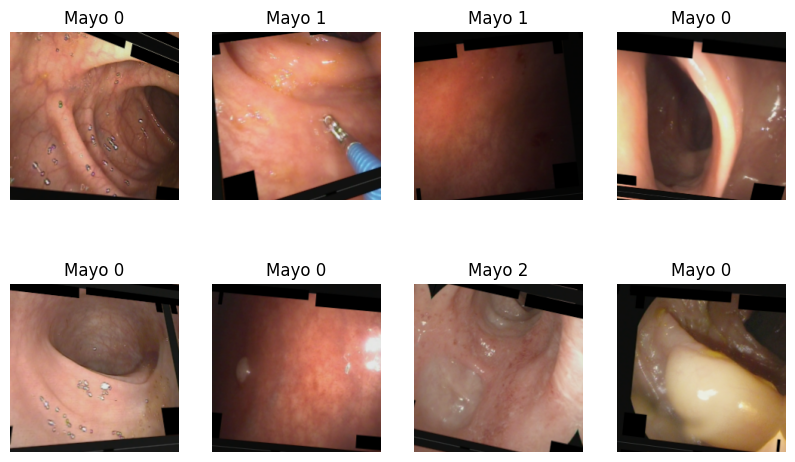

In [15]:
dls.show_batch(max_n=8, figsize=(10, 6))   # visually check a sample batch - images + augmentations look sane

In [16]:
# computing inverse-frequency weights and constructing
# Source (inverse-frequency class weights for CrossEntropyLoss with imbalanced data):
# https://dsplog.com/2026/03/05/loss-functions-for-handling-class-imbalance/#gsc.tab=0
# Source (nn.CrossEntropyLoss weight parameter):
# https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
# gives you the unique labels of your dataset, ordered precisely by how the model indexes them.
vocab = dls.vocab
class_counts = training_validation_df["label"].value_counts()
# counts_ordered = how many training images each mayo grade has, e.g. [5180, 2588, 1077, 745] for [Mayo 0, 1, 2, 3]
# (in the same order as vocab, since that's the class order the model uses internally)
counts_ordered = np.array([class_counts.get(v, 0) for v in vocab], dtype=np.float32)   # counts, in vocab order
N_total = counts_ordered.sum()
C = len(vocab)
# rare classes get a bigger weight, common classes get a smaller weight
weights = N_total / (C * counts_ordered)# inverse-frequency weights
weights = weights / weights.sum() * C   # rescale so the weights average out to 1

# use gpu if available (cuda or apple mps), otherwise fall back to cpu
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Running on: {device}")
for cls, n, w in zip(vocab, counts_ordered.astype(int), weights):
    print(f"  {cls}: count={n:>5d}  weight={w:.4f}")
# creating a tensor 
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)
# the loss function used for training - weighted so the model can't just always guess the majority class
weighted_ce_loss = nn.CrossEntropyLoss(weight=weights_tensor, reduction="mean")

Running on: cuda
  Mayo 0: count= 5180  weight=0.2709
  Mayo 1: count= 2588  weight=0.5423
  Mayo 2: count= 1077  weight=1.3031
  Mayo 3: count=  745  weight=1.8837


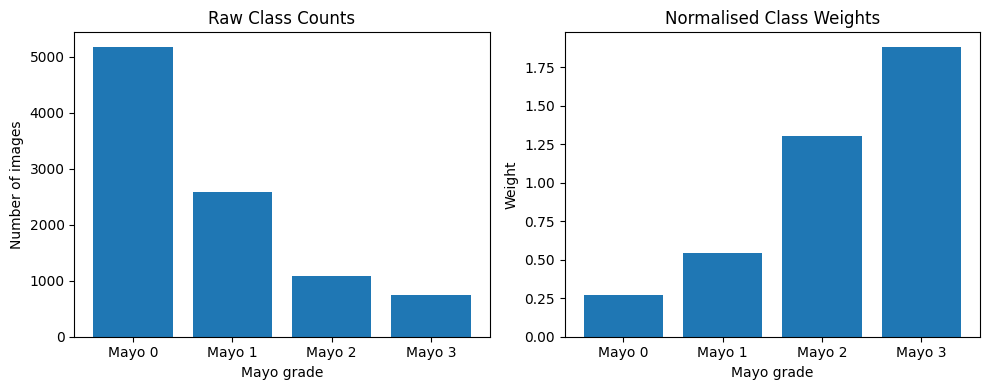

In [17]:
import matplotlib.pyplot as plt

# two charts side by side: raw image counts, and the weights we just computed
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(vocab, counts_ordered)
axes[0].set_title("Raw Class Counts")
axes[0].set_xlabel("Mayo grade")
axes[0].set_ylabel("Number of images")

axes[1].bar(vocab, weights)
axes[1].set_title("Normalised Class Weights")
axes[1].set_xlabel("Mayo grade")
axes[1].set_ylabel("Weight")

plt.tight_layout()
plt.show()

In [18]:
# Source: https://docs.fast.ai/learner.html (Metric blueprint + mk_metric)
# Concrete example: https://github.com/fastai/fastai/blob/master/fastai/metrics.py (Dice class)
# QWK formula / why cohen_kappa_score(weights="quadratic") is correct: https://www.kaggle.com/code/reighns/understanding-the-quadratic-weighted-kappa
# cohen_kappa_score API reference: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.cohen_kappa_score.html
# custom fastai metric. has to subclass Metric or fastai silently treats it as a plain function and breaks
class QuadraticWeightedKappa(Metric):
    def __init__(self):
        self.preds = []   # predictions collected so far this epoch
        self.targs = []   # true labels collected so far this epoch

    def reset(self):
        # called at the start of each epoch/validation pass - clear out the old batch
        self.preds = []
        self.targs = []

    def accumulate(self, learn):
        # called after every batch - add this batch's predictions/targets to the running list
        self.preds.extend(learn.pred.argmax(dim=1).cpu().numpy().tolist())
        self.targs.extend(learn.yb[0].cpu().numpy().tolist())

    @property
    def value(self):
        # called at the end of the epoch - actually compute the qwk score from everything collected
        if not self.preds:
            return None
        return cohen_kappa_score(self.targs, self.preds, weights="quadratic")
        # example: self.preds = [0, 2, 1, 1], self.targs = [0, 2, 2, 1] -> value = 0.87 (a float, close to 1 = good agreement)

    @property
    def name(self):
        return "qwk"   # this is the column name fastai will show for this metric

    def __repr__(self):
        return "QuadraticWeightedKappa()"

In [19]:
# the 4 architectures we're comparing
ARCHITECTURES = {
    "ResNet34": resnet34,
    "MobileNetV2": mobilenet_v2,
    "DenseNet121": densenet121,
    "EfficientNet-B0": efficientnet_b0,
}

# vision_learner needs to know where to split a model into backbone/head. it tries to auto-detect this
# by searching for a pooling layer, which fails for mobilenet_v2 (its pooling is done inline inside
# forward(), not as a registered layer) -> raises StopIteration. passing cut= directly to vision_learner
# does NOT fix this - verified that fastai 2.8.7's vision_learner silently drops its own cut= argument,
# never forwarding it to the underlying model builder. the fix that actually works: register the cut
# point in fastai's own model_meta lookup table, which the model builder DOES correctly check.
from fastai.vision.learner import model_meta, _default_meta
model_meta[mobilenet_v2] = {**_default_meta, "cut": -1}   # -1 = use mobilenet_v2.features as the backbone

if DEV_MODE:
    # quick test: only train the first architecture, 1 epoch per phase
    ARCHITECTURES = dict(list(ARCHITECTURES.items())[:1])
    EPOCHS_HEAD = 1
    EPOCHS_FULL = 1
else:
    # real run: all 4 architectures, full epoch counts
    EPOCHS_HEAD = 5
    EPOCHS_FULL = 15

print(f"DEV_MODE={DEV_MODE}  ->  architectures: {list(ARCHITECTURES)}  epochs: {EPOCHS_HEAD}+{EPOCHS_FULL}")

DEV_MODE=False  ->  architectures: ['ResNet34', 'MobileNetV2', 'DenseNet121', 'EfficientNet-B0']  epochs: 5+15


In [20]:
# Source (warmup + synchronize + perf_counter timing pattern): https://blog.speechmatics.com/cuda-timings
# torch.cuda.synchronize API reference: https://docs.pytorch.org/docs/stable/generated/torch.cuda.synchronize.html
import time

def benchmark_latency(learn, dls, n_warmup=10, n_repeats=100):
    model = learn.model
    model.eval()   # inference mode, not training mode
    original_device = next(model.parameters()).device   # remember where the model normally lives

    xb, _ = dls.valid.one_batch()   # grab one real batch just to get a properly-shaped input
    xb = xb[:1]   # keep only 1 image - real-time use is one image at a time, not a big batch

    def _time_on(device):
        model.to(device)
        x = xb.to(device)
        is_cuda = device.type == "cuda"
        is_mps = device.type == "mps"

        with torch.no_grad():   # no need to track gradients, we're not training
            # warmup passes - dont time these, the first call into a gpu model is slower (kernel compilation etc)
            for _ in range(n_warmup):
                _ = model(x)
            if is_cuda:
                torch.cuda.synchronize()   # wait for the gpu to actually finish before we start the clock
            elif is_mps:
                torch.mps.synchronize()

            times_ms = []
            for _ in range(n_repeats):
                # sync before AND after so we only time this one forward pass, nothing queued before/after
                if is_cuda:
                    torch.cuda.synchronize()
                elif is_mps:
                    torch.mps.synchronize()
                t0 = time.perf_counter()
                _ = model(x)
                if is_cuda:
                    torch.cuda.synchronize()
                elif is_mps:
                    torch.mps.synchronize()
                times_ms.append((time.perf_counter() - t0) * 1000)   # seconds -> ms

        return float(np.mean(times_ms)), float(np.std(times_ms))

    cpu_ms_mean, cpu_ms_std = _time_on(torch.device("cpu"))

    # figure out what gpu (if any) is available to also test on
    if torch.cuda.is_available():
        gpu_device = torch.device("cuda")
    elif torch.backends.mps.is_available():
        gpu_device = torch.device("mps")
    else:
        gpu_device = None

    if gpu_device is not None:
        gpu_ms_mean, gpu_ms_std = _time_on(gpu_device)
    else:
        gpu_ms_mean, gpu_ms_std = None, None

    model.to(original_device)   # put the model back where it was before we started moving it around

    gpu_str = f"{gpu_ms_mean:.2f} ± {gpu_ms_std:.2f} ms/image" if gpu_ms_mean is not None else "N/A (no CUDA/MPS available)"
    print(f"LATENCY -> CPU: {cpu_ms_mean:.2f} ± {cpu_ms_std:.2f} ms/image, GPU: {gpu_str}")

    # example return (on a machine with no CUDA/MPS, gpu fields are just None):
    # {"cpu_ms_mean": 42.31, "cpu_ms_std": 3.87, "gpu_ms_mean": 5.12, "gpu_ms_std": 0.64}
    return {
        "cpu_ms_mean": round(cpu_ms_mean, 4),
        "cpu_ms_std": round(cpu_ms_std, 4),
        "gpu_ms_mean": round(gpu_ms_mean, 4) if gpu_ms_mean is not None else None,
        "gpu_ms_std": round(gpu_ms_std, 4) if gpu_ms_std is not None else None,
    }

In [21]:
# Source (GradCAM/ClassifierOutputTarget/show_cam_on_image): https://github.com/jacobgil/pytorch-grad-cam
# Source (programmatically finding the last Conv2d layer): https://jss367.github.io/model-explainability-with-grad-cam-in-pytorch.html
# Source (dls.test_dl([...]) for single-image inference with validation transforms): https://benjaminwarner.dev/2021/10/01/inference-with-fastai
from pathlib import Path
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

def compute_gradcam(learn, image_tensor, target_class_idx):
    # produces a heatmap showing which part of the image most influenced the prediction
    model = learn.model
    model.eval()
    device = next(model.parameters()).device

    x = image_tensor.unsqueeze(0) if image_tensor.dim() == 3 else image_tensor   # add a batch dimension if needed
    x = x.to(device)

    backbone = model[0]   # the pretrained feature-extractor part of the model (not the classifier head)
    target_layer = None
    # walk every layer, keep overwriting target_layer -> ends up being the LAST Conv2d layer found
    for module in backbone.modules():
        if isinstance(module, nn.Conv2d):
            target_layer = module

    if target_layer is None:
        raise RuntimeError("No Conv2d layer found in backbone")

    targets = [ClassifierOutputTarget(target_class_idx)]   # which class we want the heatmap explained for
    with GradCAM(model=model, target_layers=[target_layer]) as cam:
        heatmap = cam(input_tensor=x, targets=targets)   # library does the actual gradcam maths

    return heatmap[0]   # (224, 224) array, values 0-1


def visualize_interpretability(learn, dls, test_df, architecture_name):
    slug = architecture_name.replace(" ", "_").replace("-", "_").lower()   # e.g. "ResNet34" -> "resnet34" for the filename
    out_dir = RESULTS_DIR / slug
    out_dir.mkdir(parents=True, exist_ok=True)

    device = next(learn.model.parameters()).device
    vocab = list(dls.vocab)
    selected = []   # will hold one chosen image (+ its gradcam) per mayo grade

    for class_idx, class_name in enumerate(vocab):
        class_df = test_df[test_df["label"] == class_name]   # only test images of this grade

        chosen_path = None
        chosen_pred_idx = None
        chosen_xb = None

        # try to find an image the model actually got RIGHT for this grade
        for img_path in class_df["path"]:
            xb = dls.test_dl([img_path], num_workers=0).one_batch()[0]   # preprocess this one image
            with torch.no_grad():
                pred = learn.model(xb.to(device))
            pred_idx = int(pred.argmax(dim=1)[0])

            if pred_idx == class_idx:
                chosen_path, chosen_pred_idx, chosen_xb = img_path, pred_idx, xb
                break   # found a correct one, stop looking

        # if none were correctly classified, just fall back to the first image of this grade
        if chosen_path is None:
            chosen_path = class_df["path"].iloc[0]
            chosen_xb = dls.test_dl([chosen_path], num_workers=0).one_batch()[0]
            with torch.no_grad():
                pred = learn.model(chosen_xb.to(device))
            chosen_pred_idx = int(pred.argmax(dim=1)[0])

        cam = compute_gradcam(learn, chosen_xb[0], chosen_pred_idx)
        orig_img = np.array(Image.open(chosen_path).convert("RGB").resize((224, 224)))

        selected.append({
            "class_name": class_name,
            "path": chosen_path,
            "pred_idx": chosen_pred_idx,
            "orig_img": orig_img,
            "cam": cam,
        })

    # build a figure: 4 columns (one per grade), 2 rows (original image / gradcam overlay)
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for col, item in enumerate(selected):
        pred_label = vocab[item["pred_idx"]]

        axes[0, col].imshow(item["orig_img"])
        axes[0, col].set_title(f"True: {item['class_name']}\nPred: {pred_label}", fontsize=10)
        axes[0, col].axis("off")

        orig_img_float = item["orig_img"].astype(np.float32) / 255.0   # show_cam_on_image expects 0-1 floats
        overlay = show_cam_on_image(orig_img_float, item["cam"], use_rgb=True, image_weight=0.55)
        axes[1, col].imshow(overlay)
        axes[1, col].set_title("Grad-CAM", fontsize=10)
        axes[1, col].axis("off")

    plt.tight_layout()
    save_path = out_dir / "gradcam.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Grad-CAM figure saved -> {save_path}")

    # example return (one (path, predicted_class_index) tuple per Mayo grade, 4 total):
    # [(Path(".../Mayo 0/UC_patient_135_10.bmp"), 0),
    #  (Path(".../Mayo 1/UC_patient_212_3.bmp"), 1),
    #  (Path(".../Mayo 2/UC_patient_338_4.bmp"), 2),
    #  (Path(".../Mayo 3/UC_patient_477_7.bmp"), 3)]
    return [(item["path"], item["pred_idx"]) for item in selected]   # so this can be logged later

In [22]:
# Source: https://docs.fast.ai/callback.schedule.html (fit_one_cycle, lr_find; the frozen/unfreeze
# two-phase discriminative-LR pattern here mirrors what Learner.fine_tune does internally, per its own docstring)
# Blog walkthrough of the same fit_one_cycle -> unfreeze -> fit_one_cycle(slice(...)) skeleton:
# https://towardsdatascience.com/why-i-use-fastai-and-you-should-too-a421f6c99508/
# Additional walkthrough of the same manual freeze -> lr_find -> fit_one_cycle -> unfreeze pattern:
# https://medium.com/@fakhar3534/unfreezing-and-transfer-learning-in-deep-learning-a31ef2ad9e8c
# fine_tune internals (fastai's own docstring shows this two-phase pattern this code mirrors):
# https://hamel.dev/notes/fastai/cv.html
def train_architecture(architecture_name, architecture_function, dls, loss_function):
    # trains ONE architecture, in two phases, and returns the trained model + its final metrics
    print(f"\n{'=' * 60}\n  Architecture: {architecture_name}\n{'=' * 60}")

    # fresh metric objects each time - qwk especially is stateful and cant be reused across models
    qwk = QuadraticWeightedKappa()
    f1 = F1Score(average="macro")
    metrics_list = [accuracy, f1, qwk]

    # builds the model with pretrained imagenet weights, new head, backbone frozen by default.
    # (mobilenet_v2's backbone/head split is handled globally via model_meta in the ARCHITECTURES cell,
    # not here - passing cut= directly to vision_learner doesn't work, see that cell's comment)
    learn = vision_learner(dls, architecture_function, loss_func=loss_function, metrics=metrics_list)

    print("\n-- Phase 1: frozen backbone --")
    # find a good learning rate for training just the new head (backbone still frozen)
    lr_head = learn.lr_find(suggest_funcs=(valley,), show_plot=False).valley
    print(f"  LR (valley): {lr_head:.2e}")
    learn.fit_one_cycle(EPOCHS_HEAD, lr_head)

    print("\n-- Phase 2: full fine-tune --")
    learn.unfreeze()   # now let every layer train, not just the head
    # find a (usually smaller) learning rate now that the whole network is unfrozen
    lr_full = learn.lr_find(suggest_funcs=(valley,), show_plot=False).valley
    print(f"  LR (valley): {lr_full:.2e}")
    # slice(lr/10, lr) = discriminative lr: early layers train slower, later layers train faster
    learn.fit_one_cycle(EPOCHS_FULL, slice(lr_full / 10, lr_full))

    final = learn.recorder.values[-1]   # metrics from the very last epoch
    metrics = {
        "training_loss": float(final[0]),
        "validation_loss": float(final[1]),
        "validation_accuracy": float(final[2]),
        "validation_f1_macro": float(final[3]),
        "validation_qwk": float(final[4]),
    }
    # example of metrics at this point:
    # {"training_loss": 0.42, "validation_loss": 0.55, "validation_accuracy": 0.83,
    #  "validation_f1_macro": 0.71, "validation_qwk": 0.68}
    print(f"\n  Done -> validation_accuracy={metrics['validation_accuracy']:.4f}  "
          f"f1={metrics['validation_f1_macro']:.4f}  qwk={metrics['validation_qwk']:.4f}")
    return learn, metrics

In [23]:
# Source (f1_score average="macro"): https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html
# Source (learn.get_preds): https://docs.fast.ai/learner.html#learner.get_preds
# Source (cohen_kappa_score for QWK): https://scikit-learn.org/stable/modules/generated/sklearn.metrics.cohen_kappa_score.html
def evaluate_on_test(learn, test_df, dls):
    # runs the trained model ONCE against the held out test set - the real, final read on performance
    test_dl = dls.test_dl(test_df["path"].tolist(), num_workers=2)
    test_preds_raw, _ = learn.get_preds(dl=test_dl)   # raw prediction scores for every test image

    label_to_idx = {v: i for i, v in enumerate(dls.vocab)}   # e.g. "Mayo 0" -> 0, "Mayo 1" -> 1, ...
    test_targets = torch.tensor([label_to_idx[l] for l in test_df["label"]])   # true labels as numbers

    pred_cls = test_preds_raw.argmax(dim=1).numpy()   # turn scores into a single predicted class per image
    true_cls = test_targets.numpy()

    test_acc = float((pred_cls == true_cls).mean())
    test_f1 = float(sklearn_f1(true_cls, pred_cls, average="macro"))
    test_qwk = float(cohen_kappa_score(true_cls, pred_cls, weights="quadratic"))

    print(f"  TEST -> acc={test_acc:.4f}  f1={test_f1:.4f}  qwk={test_qwk:.4f}")
    # also return the raw predictions - needed later for bootstrap_ci and mcnemar's test
    # example return: ({"test_acc": 0.81, "test_f1": 0.70, "test_qwk": 0.66}, array([0, 2, 1, ...]), array([0, 1, 1, ...]))
    return {"test_acc": test_acc, "test_f1": test_f1, "test_qwk": test_qwk}, pred_cls, true_cls


def clear_memory():
    # free up gpu memory between architectures so we don't run out loading 4 big models back to back
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

In [24]:
# Source (bootstrap resampling method): https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html
# Source (f1_score average="macro"): https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html
# Source (cohen_kappa_score weights="quadratic"): https://scikit-learn.org/stable/modules/generated/sklearn.metrics.cohen_kappa_score.html
from scipy.stats import bootstrap

def bootstrap_ci(true_cls, pred_cls, n_resamples=1000, random_state=42):
    # estimates a 95% confidence interval for each metric by resampling the test predictions 1000 times
    rng = np.random.default_rng(random_state)

    def _acc_stat(t, p):
        return (p == t).mean()

    def _f1_stat(t, p):
        return sklearn_f1(t, p, average="macro")

    def _qwk_stat(t, p):
        try:
            return cohen_kappa_score(t, p, weights="quadratic")
        except ValueError:
            return np.nan   # can happen if a resample ends up with only one class present

    # paired=True keeps true/pred resampled together (same indices), so they still correspond to each other
    acc_res = bootstrap(
        (true_cls, pred_cls), _acc_stat,
        n_resamples=n_resamples, paired=True, vectorized=False,
        method="percentile", confidence_level=0.95, random_state=rng,
    )
    f1_res = bootstrap(
        (true_cls, pred_cls), _f1_stat,
        n_resamples=n_resamples, paired=True, vectorized=False,
        method="percentile", confidence_level=0.95, random_state=rng,
    )
    qwk_res = bootstrap(
        (true_cls, pred_cls), _qwk_stat,
        n_resamples=n_resamples, paired=True, vectorized=False,
        method="percentile", confidence_level=0.95, random_state=rng,
    )

    # QWK's statistic can return NaN on a degenerate resample (e.g. only one class
    # present); nanpercentile on the raw bootstrap_distribution skips those safely
    # instead of letting a single NaN corrupt the whole confidence interval.
    qwk_low, qwk_high = np.nanpercentile(qwk_res.bootstrap_distribution, [2.5, 97.5])

    ci = {
        "acc_ci_low": float(acc_res.confidence_interval.low),
        "acc_ci_high": float(acc_res.confidence_interval.high),
        "f1_ci_low": float(f1_res.confidence_interval.low),
        "f1_ci_high": float(f1_res.confidence_interval.high),
        "qwk_ci_low": float(qwk_low),
        "qwk_ci_high": float(qwk_high),
    }
    # example of ci: {"acc_ci_low": 0.74, "acc_ci_high": 0.88, "f1_ci_low": 0.61,
    #                 "f1_ci_high": 0.79, "qwk_ci_low": 0.55, "qwk_ci_high": 0.77}

    print(f"BOOTSTRAP CI (95%) -> acc: [{ci['acc_ci_low']:.4f}, {ci['acc_ci_high']:.4f}], "
          f"f1: [{ci['f1_ci_low']:.4f}, {ci['f1_ci_high']:.4f}], "
          f"qwk: [{ci['qwk_ci_low']:.4f}, {ci['qwk_ci_high']:.4f}]")

    return ci

In [25]:
# Source: https://www.statsmodels.org/stable/generated/statsmodels.stats.contingency_tables.mcnemar.html
from statsmodels.stats.contingency_tables import mcnemar

def run_mcnemar_test(preds_a, preds_b, name_a="A", name_b="B"):
    # statistical test: is model A actually different from model B, or could it just be chance?
    assert np.array_equal(preds_a["true"], preds_b["true"]), \
        "Both models must be evaluated on the same test set (true labels differ)"

    true = preds_a["true"]
    correct_a = preds_a["pred"] == true
    correct_b = preds_b["pred"] == true

    # build the 2x2 table: how often were both right, both wrong, or only one of them right
    both_correct      = int((correct_a & correct_b).sum())
    a_correct_b_wrong = int((correct_a & ~correct_b).sum())
    a_wrong_b_correct = int((~correct_a & correct_b).sum())
    both_wrong        = int((~correct_a & ~correct_b).sum())

    table = [[both_correct, a_correct_b_wrong],
             [a_wrong_b_correct, both_wrong]]

    n_disagreements = a_correct_b_wrong + a_wrong_b_correct   # cases where the two models disagreed
    is_exact = n_disagreements < 25   # exact binomial for small samples, chi-squared otherwise

    result = mcnemar(table, exact=is_exact, correction=not is_exact)

    print(f"McNemar {name_a} vs {name_b}: p={result.pvalue:.4f} (n_disagreements={n_disagreements})")

    # example return: {"statistic": 4.17, "p_value": 0.0412, "n_disagreements": 18}
    return {
        "statistic": float(result.statistic),
        "p_value": float(result.pvalue),   # < 0.05 = the difference is probably real, not just chance
        "n_disagreements": n_disagreements,
    }


  Architecture: ResNet34
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 244MB/s]



-- Phase 1: frozen backbone --


<div></div>

  LR (valley): 6.92e-04


...

<div></div>

  LR (valley): 8.32e-06


epoch,train_loss,valid_loss,accuracy,f1_score,qwk,time
0,0.803649,0.735514,0.741397,0.685065,0.821577,00:21
1,0.820606,0.731508,0.737748,0.686932,0.816783,00:21
2,0.768186,0.742792,0.749218,0.684945,0.825830,00:21
3,0.803069,0.737919,0.746090,0.686535,0.822928,00:21
4,0.736455,0.714380,0.731491,0.683567,0.812727,00:21
5,0.789711,0.720338,0.749739,0.697471,0.822020,00:21
6,0.769266,0.706538,0.743483,0.692594,0.819689,00:21
7,0.731259,0.699366,0.753389,0.703140,0.829191,00:21
8,0.753531,0.689966,0.742961,0.696099,0.821348,00:21
9,0.739688,0.683251,0.755474,0.704312,0.828990,00:21



  Done -> validation_accuracy=0.7628  f1=0.7072  qwk=0.8316


  TEST -> acc=0.7236  f1=0.6639  qwk=0.8027
BOOTSTRAP CI (95%) -> acc: [0.7022, 0.7444], f1: [0.6332, 0.6925], qwk: [0.7780, 0.8240]
LATENCY -> CPU: 33.35 ± 1.20 ms/image, GPU: 9.79 ± 0.22 ms/image


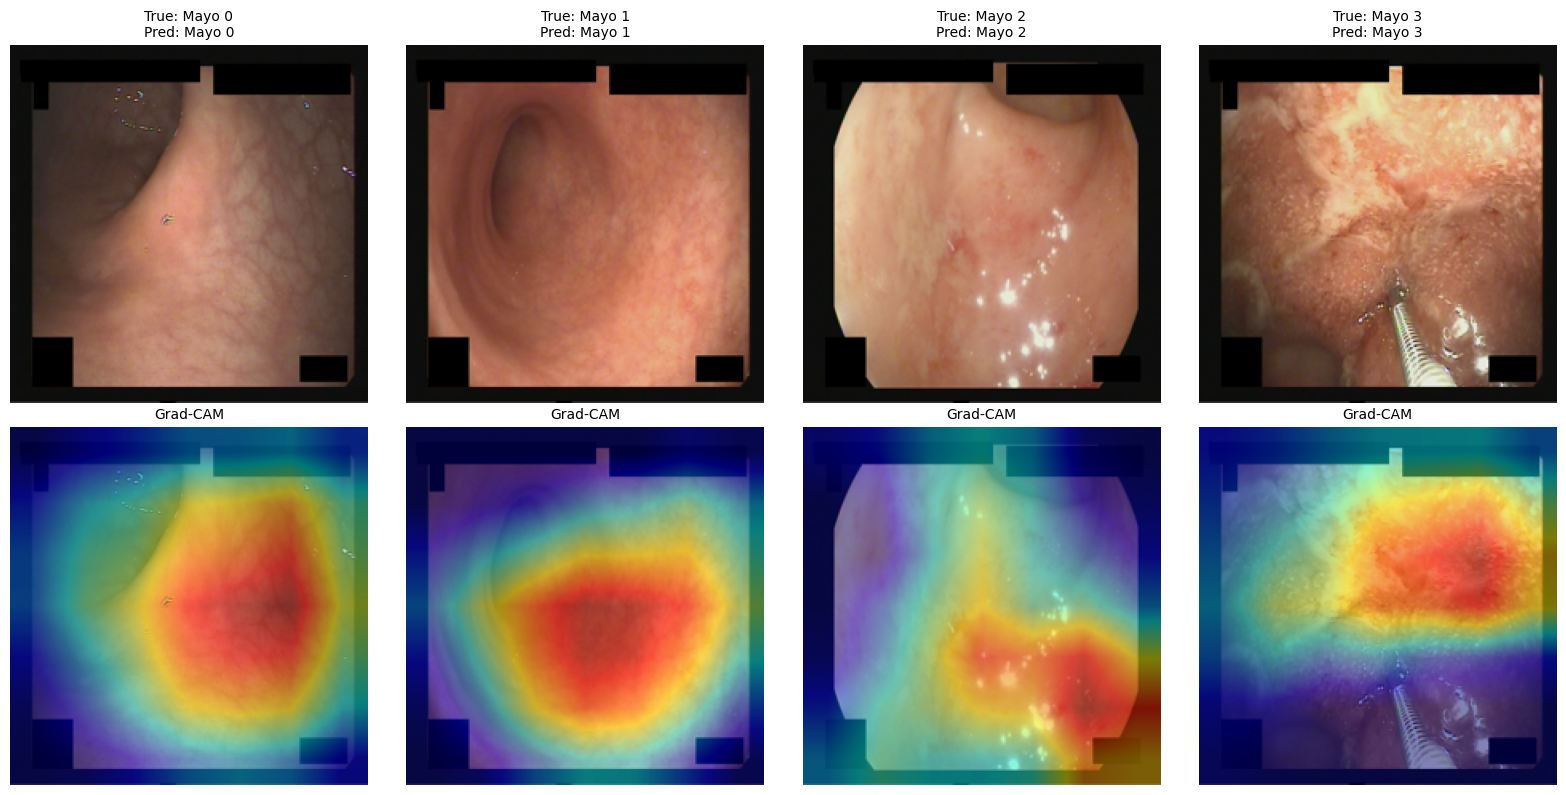

Grad-CAM figure saved -> /content/drive/MyDrive/Masters/results/resnet34/gradcam.png


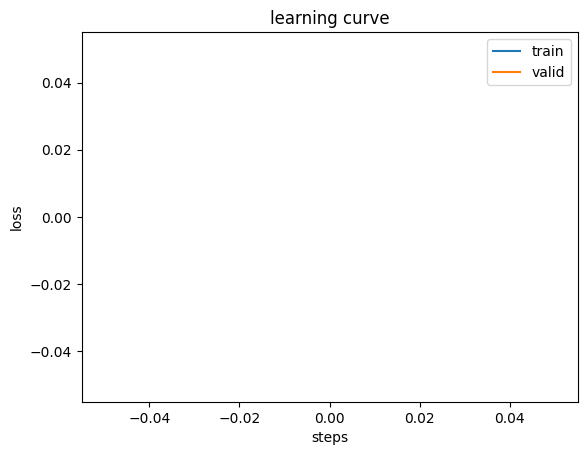

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[checkpoint] saved 1/4 architectures -> /content/drive/MyDrive/Masters/results/final_results.csv

  Architecture: MobileNetV2
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 231MB/s]



-- Phase 1: frozen backbone --


<div></div>

...

<div></div>

  LR (valley): 8.32e-06


epoch,train_loss,valid_loss,accuracy,f1_score,qwk,time
0,0.652463,0.644503,0.769552,0.726727,0.846926,00:21
1,0.623568,0.660128,0.771637,0.722065,0.848245,00:21
2,0.634124,0.631350,0.764859,0.725972,0.843959,00:21
3,0.633026,0.627704,0.760688,0.722812,0.844244,00:21
4,0.643060,0.621927,0.759645,0.722915,0.846481,00:21
5,0.620192,0.652431,0.769552,0.716889,0.848404,00:21
6,0.638566,0.635801,0.761731,0.719679,0.846770,00:21
7,0.661550,0.641626,0.760167,0.714901,0.844973,00:21
8,0.603680,0.625616,0.766945,0.729364,0.851884,00:21
9,0.616446,0.626254,0.761210,0.722728,0.846237,00:21



  Done -> validation_accuracy=0.7669  f1=0.7219  qwk=0.8497


  TEST -> acc=0.7503  f1=0.6826  qwk=0.8299
BOOTSTRAP CI (95%) -> acc: [0.7284, 0.7716], f1: [0.6542, 0.7109], qwk: [0.8079, 0.8483]
LATENCY -> CPU: 24.55 ± 0.71 ms/image, GPU: 11.91 ± 0.25 ms/image


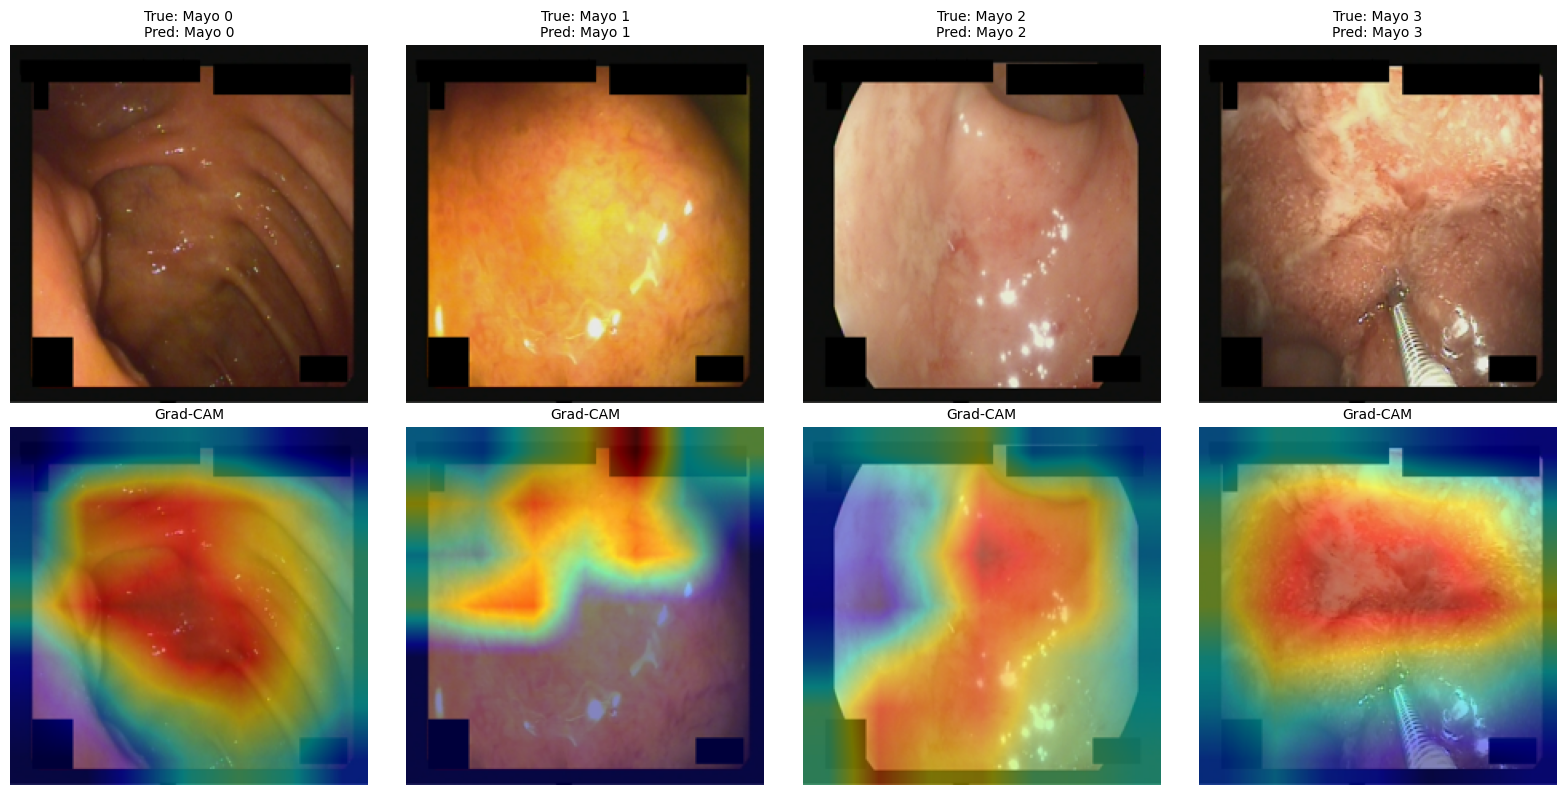

Grad-CAM figure saved -> /content/drive/MyDrive/Masters/results/mobilenetv2/gradcam.png


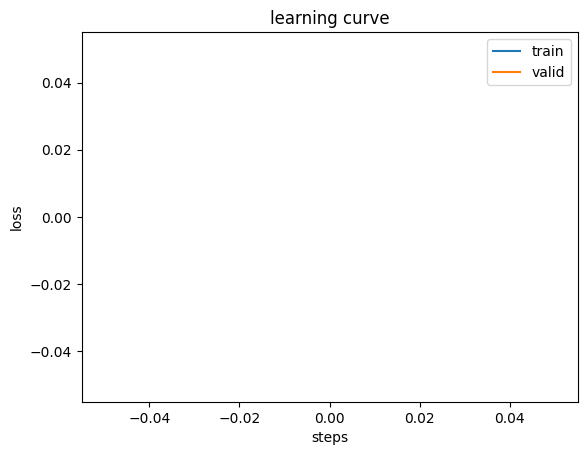

[checkpoint] saved 2/4 architectures -> /content/drive/MyDrive/Masters/results/final_results.csv

  Architecture: DenseNet121
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 236MB/s]



-- Phase 1: frozen backbone --


<div></div>

  LR (valley): 8.32e-04


...

<div></div>

  LR (valley): 4.37e-05


epoch,train_loss,valid_loss,accuracy,f1_score,qwk,time
0,0.626028,0.614757,0.752346,0.722602,0.841424,00:37
1,0.643669,0.611624,0.747132,0.713420,0.836140,00:37
2,0.633279,0.621082,0.735141,0.705724,0.824228,00:37
3,0.636732,0.605743,0.747654,0.713057,0.838657,00:37
4,0.615331,0.608671,0.765902,0.724960,0.849790,00:37
5,0.602428,0.612837,0.750782,0.711628,0.837661,00:38
6,0.555155,0.610627,0.760167,0.719462,0.843668,00:38
7,0.565473,0.608315,0.742961,0.707063,0.832618,00:38
8,0.537152,0.624512,0.766423,0.728064,0.844813,00:37
9,0.547415,0.605562,0.777894,0.729692,0.854081,00:38



  Done -> validation_accuracy=0.7669  f1=0.7305  qwk=0.8479


  TEST -> acc=0.7420  f1=0.6816  qwk=0.8140
BOOTSTRAP CI (95%) -> acc: [0.7200, 0.7622], f1: [0.6522, 0.7105], qwk: [0.7910, 0.8353]
LATENCY -> CPU: 74.56 ± 1.69 ms/image, GPU: 33.79 ± 0.94 ms/image


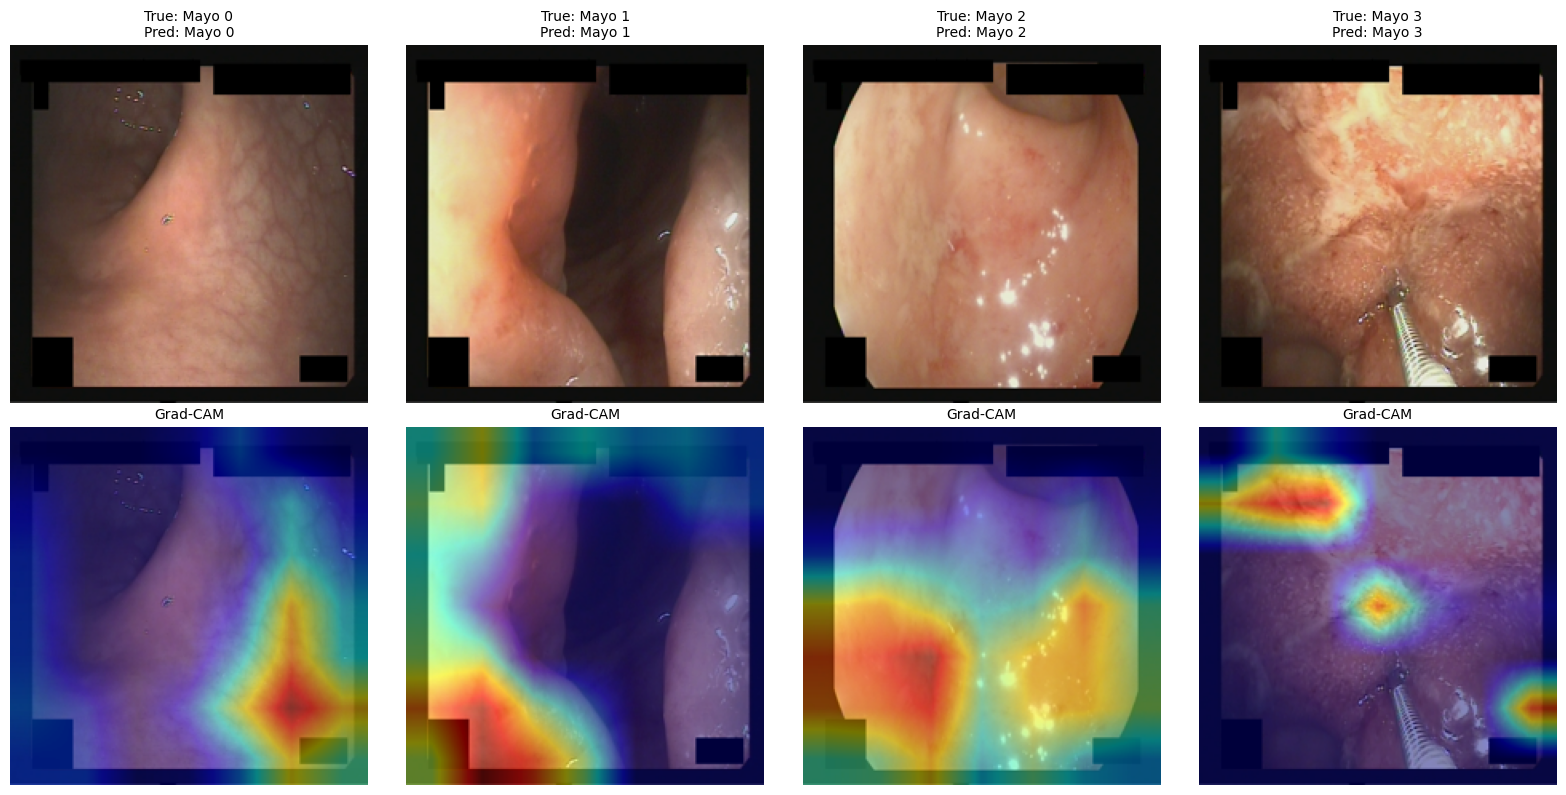

Grad-CAM figure saved -> /content/drive/MyDrive/Masters/results/densenet121/gradcam.png


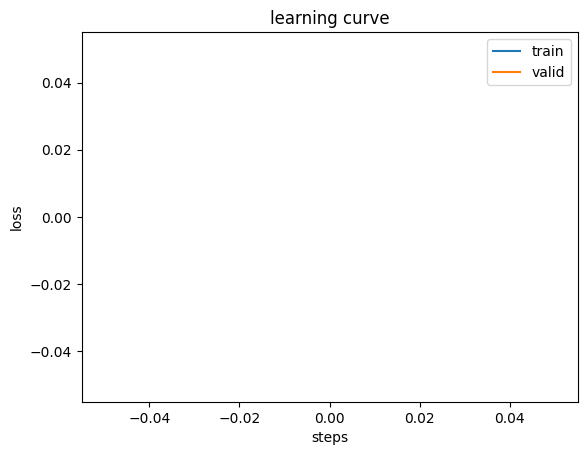

[checkpoint] saved 3/4 architectures -> /content/drive/MyDrive/Masters/results/final_results.csv

  Architecture: EfficientNet-B0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 20.5M/20.5M [00:00<00:00, 234MB/s]



-- Phase 1: frozen backbone --


<div></div>

  LR (valley): 3.98e-04


...

<div></div>

  LR (valley): 3.98e-06


epoch,train_loss,valid_loss,accuracy,f1_score,qwk,time
0,0.971548,0.851153,0.680396,0.606494,0.738294,00:25
1,1.025346,0.846600,0.679353,0.604442,0.739551,00:25
2,0.961810,0.862807,0.672054,0.591234,0.722222,00:25
3,0.965625,0.841302,0.680918,0.606851,0.739940,00:26
4,0.950812,0.842395,0.678832,0.607848,0.737035,00:26
5,0.951101,0.827668,0.689781,0.623815,0.750860,00:26
6,0.967967,0.828091,0.679353,0.611823,0.736300,00:26
7,0.970246,0.816080,0.680918,0.621097,0.744887,00:26
8,0.946633,0.830331,0.686653,0.613534,0.748616,00:25
9,0.934382,0.823035,0.679353,0.618615,0.731102,00:25



  Done -> validation_accuracy=0.6835  f1=0.6188  qwk=0.7426


  TEST -> acc=0.6785  f1=0.6047  qwk=0.7403
BOOTSTRAP CI (95%) -> acc: [0.6554, 0.6987], f1: [0.5763, 0.6326], qwk: [0.7066, 0.7714]
LATENCY -> CPU: 32.38 ± 0.75 ms/image, GPU: 17.44 ± 0.40 ms/image


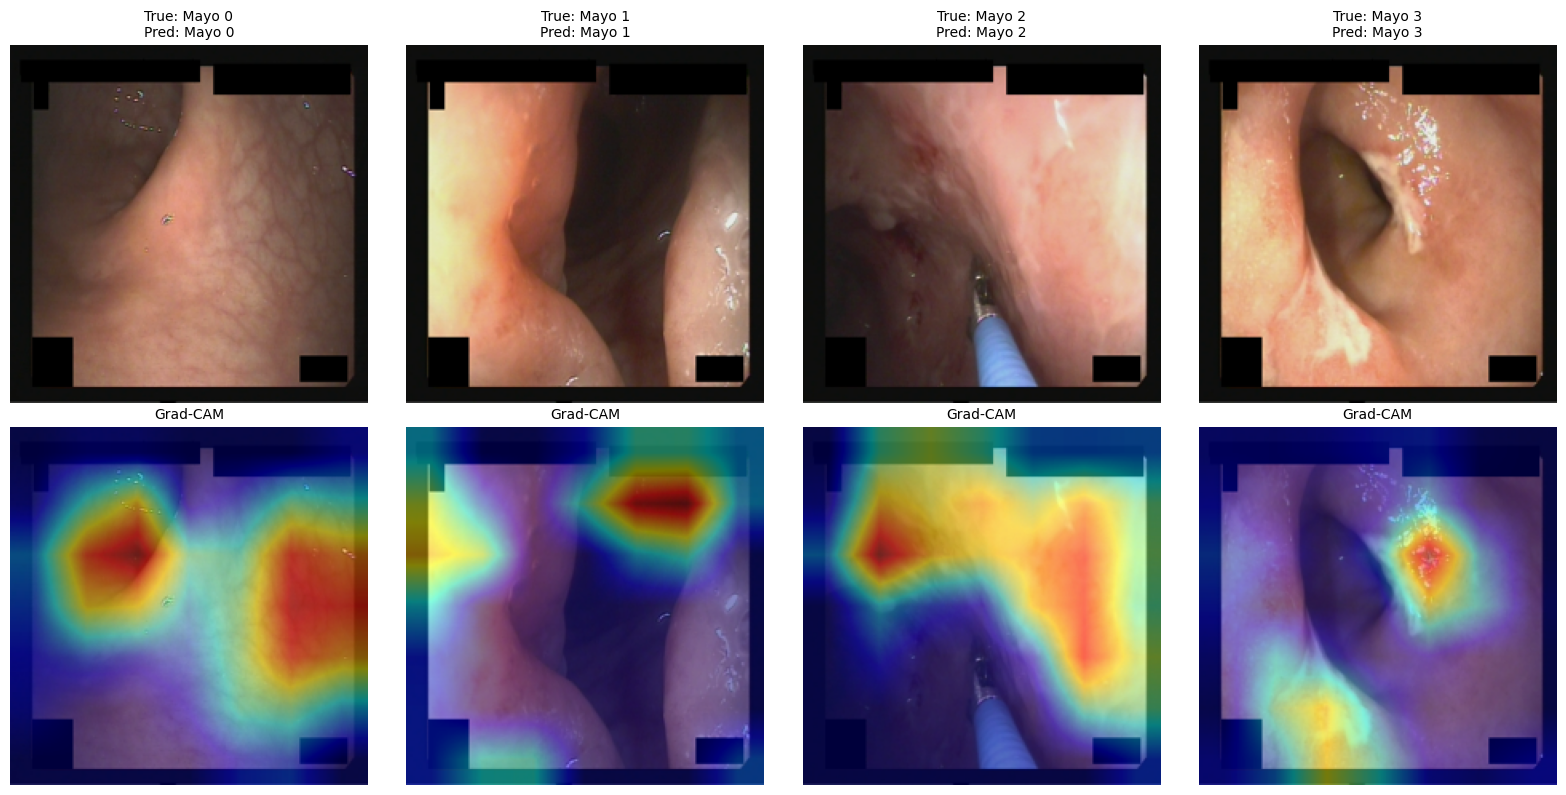

Grad-CAM figure saved -> /content/drive/MyDrive/Masters/results/efficientnet_b0/gradcam.png


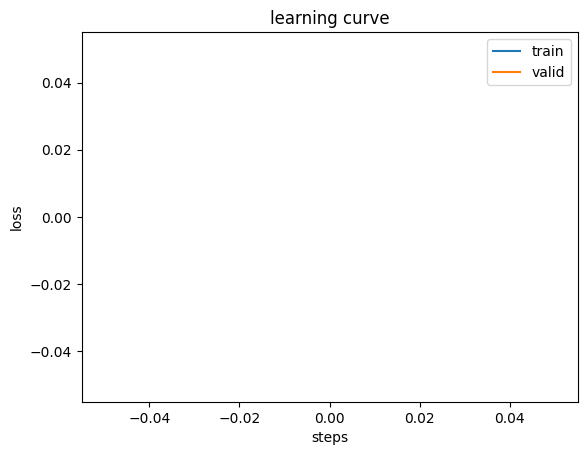

[checkpoint] saved 4/4 architectures -> /content/drive/MyDrive/Masters/results/final_results.csv


,Accuracy,Acc 95% CI,F1 (macro),F1 95% CI,QWK,QWK 95% CI
model,,,,,,
MobileNetV2,0.7503,"[0.7284, 0.7716]",0.6826,"[0.6542, 0.7109]",0.8299,"[0.8079, 0.8483]"
DenseNet121,0.7420,"[0.7200, 0.7622]",0.6816,"[0.6522, 0.7105]",0.8140,"[0.7910, 0.8353]"
ResNet34,0.7236,"[0.7022, 0.7444]",0.6639,"[0.6332, 0.6925]",0.8027,"[0.7780, 0.8240]"
EfficientNet-B0,0.6785,"[0.6554, 0.6987]",0.6047,"[0.5763, 0.6326]",0.7403,"[0.7066, 0.7714]"


Saved -> /content/drive/MyDrive/Masters/results/performance_metrics.csv


,Validation Accuracy,Validation F1 (macro),Validation QWK
model,,,
MobileNetV2,0.7669,0.7219,0.8497
DenseNet121,0.7669,0.7305,0.8479
ResNet34,0.7628,0.7072,0.8316
EfficientNet-B0,0.6835,0.6188,0.7426


Saved -> /content/drive/MyDrive/Masters/results/validation_metrics.csv


,CPU (ms/image),GPU (ms/image)
model,,
MobileNetV2,24.55 ± 0.71,11.91 ± 0.25
DenseNet121,74.56 ± 1.69,33.79 ± 0.94
ResNet34,33.35 ± 1.20,9.79 ± 0.22
EfficientNet-B0,32.38 ± 0.75,17.44 ± 0.40


Saved -> /content/drive/MyDrive/Masters/results/latency_metrics.csv


In [26]:
all_results = []      # one dict per architecture, becomes the final results table
stored_preds = {}      # raw predictions per architecture, needed later for mcnemar's test

for architecture_name, architecture_function in ARCHITECTURES.items():
    # train this architecture (two phases), then run every evaluation on it
    learn, training_metrics = train_architecture(architecture_name, architecture_function, dls, weighted_ce_loss)
    test_metrics, pred_cls, true_cls = evaluate_on_test(learn, test_df, dls)
    ci = bootstrap_ci(true_cls, pred_cls)
    stored_preds[architecture_name] = {"pred": pred_cls, "true": true_cls}
    latency_metrics = benchmark_latency(learn, dls)
    gradcam_selected = visualize_interpretability(learn, dls, test_df, architecture_name)

    learn.recorder.plot_loss()   # show train vs validation loss curve for this architecture
    plt.show()

    # collect everything about this architecture into one row for the final table
    all_results.append({
        "model": architecture_name,
        "validation_accuracy": round(training_metrics["validation_accuracy"], 4),
        "validation_f1_macro": round(training_metrics["validation_f1_macro"], 4),
        "validation_qwk": round(training_metrics["validation_qwk"], 4),
        "test_accuracy": round(test_metrics["test_acc"], 4),
        "test_f1_macro": round(test_metrics["test_f1"], 4),
        "test_qwk": round(test_metrics["test_qwk"], 4),
        "acc_ci_low": round(ci["acc_ci_low"], 4),
        "acc_ci_high": round(ci["acc_ci_high"], 4),
        "f1_ci_low": round(ci["f1_ci_low"], 4),
        "f1_ci_high": round(ci["f1_ci_high"], 4),
        "qwk_ci_low": round(ci["qwk_ci_low"], 4),
        "qwk_ci_high": round(ci["qwk_ci_high"], 4),
        "cpu_ms_mean": latency_metrics["cpu_ms_mean"],
        "cpu_ms_std": latency_metrics["cpu_ms_std"],
        "gpu_ms_mean": latency_metrics["gpu_ms_mean"],
        "gpu_ms_std": latency_metrics["gpu_ms_std"],
        "gradcam_selected": gradcam_selected,
    })
    # example of one row just appended to all_results:
    # {"model": "ResNet34", "validation_accuracy": 0.83, "validation_f1_macro": 0.71, "validation_qwk": 0.68,
    #  "test_accuracy": 0.81, "test_f1_macro": 0.70, "test_qwk": 0.66,
    #  "acc_ci_low": 0.74, "acc_ci_high": 0.88, "f1_ci_low": 0.61, "f1_ci_high": 0.79,
    #  "qwk_ci_low": 0.55, "qwk_ci_high": 0.77,
    #  "cpu_ms_mean": 42.31, "cpu_ms_std": 3.87, "gpu_ms_mean": 5.12, "gpu_ms_std": 0.64,
    #  "gradcam_selected": [(Path(".../Mayo 0/..."), 0), ...]}

    # checkpoint: resave final_results.csv after every architecture, not just once at the very end -
    # so an overnight colab disconnect only loses whatever's mid-training, not every architecture already done
    pd.DataFrame(all_results).set_index("model").to_csv(RESULTS_DIR / "final_results.csv")
    print(f"[checkpoint] saved {len(all_results)}/{len(ARCHITECTURES)} architectures -> {RESULTS_DIR / 'final_results.csv'}")

    del learn          # free up the model...
    clear_memory()      # ...and actually release the memory before loading the next architecture

# build one big table, one row per architecture, sorted best-to-worst by test qwk
results_df = pd.DataFrame(all_results).set_index("model")
results_df = results_df.sort_values("test_qwk", ascending=False)
# example of results_df (indexed by model name, one row per architecture, sorted by test_qwk):
#                  validation_accuracy  ...  test_qwk  ...  gradcam_selected
# ResNet34                        0.83  ...      0.66  ...  [(...), (...), (...), (...)]
# DenseNet121                     0.80  ...      0.63  ...  [(...), (...), (...), (...)]
# MobileNetV2                     0.77  ...      0.59  ...  [(...), (...), (...), (...)]

from IPython.display import display

def _format_ci(low, high):
    return f"[{low:.4f}, {high:.4f}]"   # turn two numbers into one readable "[low, high]" string

def _format_mean_std(mean, std):
    if mean is None or std is None:
        return "N/A"
    return f"{mean:.2f} ± {std:.2f}"

# a smaller, cleaner table just for accuracy/f1/qwk + their confidence intervals
perf_table = pd.DataFrame({
    "Accuracy": results_df["test_accuracy"].round(4),
    "Acc 95% CI": [_format_ci(lo, hi) for lo, hi in zip(results_df["acc_ci_low"], results_df["acc_ci_high"])],
    "F1 (macro)": results_df["test_f1_macro"].round(4),
    "F1 95% CI": [_format_ci(lo, hi) for lo, hi in zip(results_df["f1_ci_low"], results_df["f1_ci_high"])],
    "QWK": results_df["test_qwk"].round(4),
    "QWK 95% CI": [_format_ci(lo, hi) for lo, hi in zip(results_df["qwk_ci_low"], results_df["qwk_ci_high"])],
}, index=results_df.index)
# example of perf_table:
# model         Accuracy   Acc 95% CI          F1 (macro)   F1 95% CI           QWK    QWK 95% CI
# ResNet34      0.8100     [0.7400, 0.8800]    0.7000       [0.6100, 0.7900]    0.6600 [0.5500, 0.7700]

# same idea but for validation metrics only
validation_table = pd.DataFrame({
    "Validation Accuracy": results_df["validation_accuracy"].round(4),
    "Validation F1 (macro)": results_df["validation_f1_macro"].round(4),
    "Validation QWK": results_df["validation_qwk"].round(4),
}, index=results_df.index)
# example of validation_table:
# model         Validation Accuracy   Validation F1 (macro)   Validation QWK
# ResNet34      0.8300                0.7100                  0.6800

# and one for latency, combining mean+std into one readable string per device
latency_table = pd.DataFrame({
    "CPU (ms/image)": [_format_mean_std(m, s) for m, s in zip(results_df["cpu_ms_mean"], results_df["cpu_ms_std"])],
    "GPU (ms/image)": [_format_mean_std(m, s) for m, s in zip(results_df["gpu_ms_mean"], results_df["gpu_ms_std"])],
}, index=results_df.index)
# example of latency_table:
# model         CPU (ms/image)     GPU (ms/image)
# ResNet34      42.31 ± 3.87       5.12 ± 0.64

# shared css styling for all three tables below (bold caption, aligned cells)
_table_styles = [
    {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"),
                                       ("text-align", "left"), ("padding-bottom", "6px")]},
    {"selector": "th", "props": [("text-align", "center"), ("padding", "4px 12px")]},
    {"selector": "td", "props": [("text-align", "center"), ("padding", "4px 12px")]},
]

# show + save each of the three tables
display(
    perf_table.style
    .format({"Accuracy": "{:.4f}", "F1 (macro)": "{:.4f}", "QWK": "{:.4f}"})
    .set_caption("Performance Metrics (Test Set)")
    .set_table_styles(_table_styles)
)
perf_table.to_csv(RESULTS_DIR / "performance_metrics.csv")
print(f"Saved -> {RESULTS_DIR / 'performance_metrics.csv'}")

display(
    validation_table.style
    .format({"Validation Accuracy": "{:.4f}", "Validation F1 (macro)": "{:.4f}", "Validation QWK": "{:.4f}"})
    .set_caption("Validation Metrics")
    .set_table_styles(_table_styles)
)
validation_table.to_csv(RESULTS_DIR / "validation_metrics.csv")
print(f"Saved -> {RESULTS_DIR / 'validation_metrics.csv'}")

display(
    latency_table.style
    .set_caption("Latency (Inference Cost)")
    .set_table_styles(_table_styles)
)
latency_table.to_csv(RESULTS_DIR / "latency_metrics.csv")
print(f"Saved -> {RESULTS_DIR / 'latency_metrics.csv'}")

In [27]:
baseline_name = "ResNet34"   # every other architecture gets compared against this one

mcnemar_results = []
for architecture_name, preds in stored_preds.items():
    if architecture_name == baseline_name:
        continue   # dont compare resnet34 against itself
    result = run_mcnemar_test(stored_preds[baseline_name], preds, name_a=baseline_name, name_b=architecture_name)
    mcnemar_results.append({
        "comparison": f"{baseline_name} vs {architecture_name}",
        "p_value": round(result["p_value"], 4),
        "n_disagreements": result["n_disagreements"],
        "significant": result["p_value"] < 0.05,   # is the difference likely real, not just chance
    })

mcnemar_df = pd.DataFrame(mcnemar_results)
# example of mcnemar_df:
# comparison                    p_value   n_disagreements   significant
# ResNet34 vs MobileNetV2       0.0412    18                True
# ResNet34 vs DenseNet121       0.2841    22                False
# ResNet34 vs EfficientNet-B0   0.0019    31                True
print("\nMcNEMAR PAIRWISE COMPARISONS (baseline: ResNet34):")
print(mcnemar_df.to_string(index=False))

mcnemar_out_path = RESULTS_DIR / "mcnemar_pairwise.csv"
mcnemar_out_path.parent.mkdir(parents=True, exist_ok=True)
mcnemar_df.to_csv(mcnemar_out_path, index=False)
print(f"\nSaved -> {mcnemar_out_path}")

McNemar ResNet34 vs MobileNetV2: p=0.0089 (n_disagreements=283)
McNemar ResNet34 vs DenseNet121: p=0.0664 (n_disagreements=267)
McNemar ResNet34 vs EfficientNet-B0: p=0.0001 (n_disagreements=376)

McNEMAR PAIRWISE COMPARISONS (baseline: ResNet34):
                 comparison  p_value  n_disagreements  significant
    ResNet34 vs MobileNetV2   0.0089              283         True
    ResNet34 vs DenseNet121   0.0664              267        False
ResNet34 vs EfficientNet-B0   0.0001              376         True

Saved -> /content/drive/MyDrive/Masters/results/mcnemar_pairwise.csv


In [28]:
# save the full results table (every column, every architecture) as one csv for safe keeping
final_results_path = RESULTS_DIR / "final_results.csv"
results_df.to_csv(final_results_path)
print(f"Final results saved -> {final_results_path}")

Final results saved -> /content/drive/MyDrive/Masters/results/final_results.csv


In [29]:
import base64
import shutil
from IPython.display import HTML, display

# zip up everything in RESULTS_DIR into one file
zip_path = shutil.make_archive("/content/benchmarking_results", "zip", RESULTS_DIR)
zip_size_mb = Path(zip_path).stat().st_size / (1024 * 1024)
print(f"Zipped results -> {zip_path} ({zip_size_mb:.2f} MB)")

if zip_size_mb < 2:
    # embed the zip directly into an html link so clicking it downloads it (google.colab.files.download doesnt work in vscode)
    with open(zip_path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    href = (
        f'<a download="benchmarking_results.zip" '
        f'href="data:application/zip;base64,{b64}">'
        f'Click to download benchmarking_results.zip</a>'
    )
    display(HTML(href))
else:
    # too big to embed as a link (chrome caps this around 2mb) - just point at drive instead
    print(
        f"Zip is {zip_size_mb:.1f} MB -- too large for an in-notebook download link.\n"
        f"Grab it from Google Drive instead: {RESULTS_DIR}\n"
        "(open drive.google.com, or install Google Drive for Desktop to sync it locally)"
    )

Zipped results -> /content/benchmarking_results.zip (6.79 MB)
Zip is 6.8 MB -- too large for an in-notebook download link.
Grab it from Google Drive instead: /content/drive/MyDrive/Masters/results
(open drive.google.com, or install Google Drive for Desktop to sync it locally)
